In [7]:
import os
import numpy as np
import torch
from glob import glob
from monai.metrics import DiceMetric

pred_dir = "/home/jovyan/thesis_project/Swin_LiteMedSAM/outputs"
gt_dir = "/home/jovyan/thesis_project/datasets/INbreast/INbreast Release 1.0/npz_img_mask_masses"

In [8]:
dice_metric = DiceMetric(include_background=False, reduction="mean")
per_case = []

for pred_file in sorted(glob(os.path.join(pred_dir, "*.npz"))):
    name = os.path.basename(pred_file)
    gt_file = os.path.join(gt_dir, name)

    pred_npz = np.load(pred_file)
    gt_npz = np.load(gt_file)

    pred_seg = pred_npz["segs"]
    gt_mask = gt_npz["gts"]

    pred = torch.as_tensor(pred_seg > 0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    gt = torch.as_tensor(gt_mask > 0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    score = dice_metric(y_pred=pred, y=gt)
    per_case.append((name, score.item()))

mean_dice = sum(s for _, s in per_case) / len(per_case)
print("Mean Dice:", mean_dice)

for name, score in per_case:
    print(f"{name}: {score:.4f}")

Mean Dice: 0.7902619906191556
20586908_6c613a14b80a8591_MG_R_CC_ANON.npz: 0.5892
20586934_6c613a14b80a8591_MG_L_CC_ANON.npz: 0.8509
20586960_6c613a14b80a8591_MG_R_ML_ANON.npz: 0.7803
20586986_6c613a14b80a8591_MG_L_ML_ANON.npz: 0.7332
20587612_f4b2d377f43ba0bd_MG_R_CC_ANON.npz: 0.7866
20587664_f4b2d377f43ba0bd_MG_R_ML_ANON.npz: 0.8525
20587758_81cd83d2f4d78528_MG_L_CC_ANON.npz: 0.7891
20587810_81cd83d2f4d78528_MG_L_ML_ANON.npz: 0.6498
20587902_8dbbd4e51f549ff0_MG_R_CC_ANON.npz: 0.8380
20587928_8dbbd4e51f549ff0_MG_R_ML_ANON.npz: 0.8653
20587994_024ee3569b2605dc_MG_R_CC_ANON.npz: 0.7370
20588046_024ee3569b2605dc_MG_R_ML_ANON.npz: 0.8047
20588190_8d0b9620c53c0268_MG_L_CC_ANON.npz: 0.7866
20588216_8d0b9620c53c0268_MG_L_ML_ANON.npz: 0.8656
20588308_493155e17143edef_MG_L_ML_ANON.npz: 0.8696
20588334_493155e17143edef_MG_L_CC_ANON.npz: 0.7092
20588536_bf1a6aaadb05e3df_MG_L_ML_ANON.npz: 0.8860
20588562_bf1a6aaadb05e3df_MG_L_CC_ANON.npz: 0.9477
20588680_036aff49b8ac84f0_MG_L_ML_ANON.npz: 0.9383
2

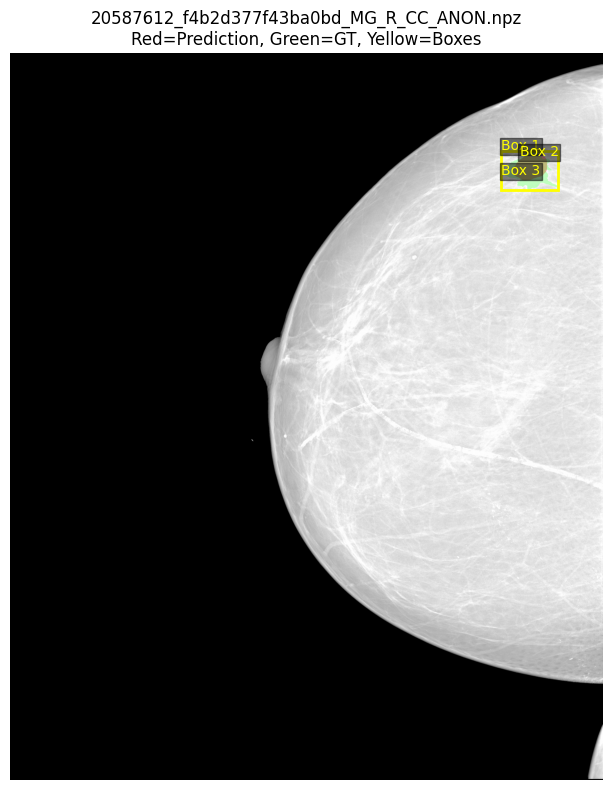

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_npz_prediction(
    input_npz_path: str,
    pred_npz_path: str,
    show_gt: bool = True,
    figsize=(8, 8),
    alpha_pred: float = 0.35,
    alpha_gt: float = 0.25,
):
    """
    Visualize image, predicted segmentation, optional GT mask, and input boxes.

    Expects:
      input_npz_path: .npz with keys:
          - imgs: (H, W, 3)
          - boxes: (N, 4)
          - optional gts: (H, W) or (1, H, W)
      pred_npz_path: .npz with key:
          - segs: (H, W)

    Boxes are assumed to be [x_min, y_min, x_max, y_max] in original image coords.
    """

    inp = np.load(input_npz_path, allow_pickle=True)
    pred = np.load(pred_npz_path, allow_pickle=True)

    img = inp["imgs"]
    boxes = inp["boxes"]
    segs = pred["segs"]

    if img.ndim != 3 or img.shape[-1] != 3:
        raise ValueError(f"`imgs` must have shape (H, W, 3), got {img.shape}")

    if boxes.ndim == 1:
        boxes = boxes[None, :]

    gt = None
    if show_gt and "gts" in inp:
        gt = inp["gts"]
        if gt.ndim == 3 and gt.shape[0] == 1:
            gt = gt[0]
        gt = (gt > 0).astype(np.uint8)

    pred_bin = (segs > 0).astype(np.uint8)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img, cmap=None if img.ndim == 3 else "gray")

    # Pred overlay in red
    pred_overlay = np.zeros((*pred_bin.shape, 4), dtype=np.float32)
    pred_overlay[..., 0] = 1.0
    pred_overlay[..., 3] = pred_bin * alpha_pred
    ax.imshow(pred_overlay)

    # GT overlay in green
    if gt is not None:
        gt_overlay = np.zeros((*gt.shape, 4), dtype=np.float32)
        gt_overlay[..., 1] = 1.0
        gt_overlay[..., 3] = gt * alpha_gt
        ax.imshow(gt_overlay)

    # Draw boxes
    for i, box in enumerate(boxes, start=1):
        x0, y0, x1, y1 = box
        rect = Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            edgecolor="yellow",
            linewidth=2,
        )
        ax.add_patch(rect)
        ax.text(
            x0,
            max(0, y0 - 5),
            f"Box {i}",
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.5, pad=1),
        )

    title = os.path.basename(pred_npz_path)
    if gt is not None:
        ax.set_title(f"{title}\nRed=Prediction, Green=GT, Yellow=Boxes")
    else:
        ax.set_title(f"{title}\nRed=Prediction, Yellow=Boxes")

    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    
sample="20587612_f4b2d377f43ba0bd_MG_R_CC_ANON.npz"
    
visualize_npz_prediction(
    input_npz_path=gt_dir+ f"/{sample}",
    pred_npz_path=pred_dir+f"/{sample}",
)